In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_heatmap(x, t, w):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    c = ax.contourf(x, t, w.T, levels=50, cmap='RdBu_r')
    plt.colorbar(c, ax=ax, label='u(x, t)')
    
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_title('Heatmap — Heat equation')
    plt.tight_layout()
    plt.show()

In [3]:
def thomas_algorithm(a,b,d,B):
    N = len(d)

    y = np.zeros(N)

    a[0] = a[0]/d[0]
    B[0] = B[0]/d[0]

    for i in range(1, N-1):
        a[i] = a[i]/(d[i] - b[i-1]*a[i-1])
        B[i] = (B[i] - b[i-1]*B[i-1])/(d[i] - b[i-1]*a[i-1])

    B[N-1] = (B[N-1] - b[N-2]*B[N-2])/(d[N-1] - b[N-2]*a[N-2])

    y[N-1] = B[N-1]

    for i in range(N-2, -1, -1):
        y[i] = B[i] - a[i]*y[i+1]

    return y

In [4]:
from matplotlib.lines import lineStyles
from mpl_toolkits.mplot3d import Axes3D
def plot_grafico(x,t,w):
  plt.figure(figsize = (15,8))
  X, Y = np.meshgrid(x, t) # Changed from np.meshgrid(x, y) to np.meshgrid(x, t)
  X_real,Y_real = np.meshgrid(x, t) # Changed to use the same x and t as the numerical solution for consistency

  fig = plt.figure()
  ax = fig.add_subplot(111, projection='3d')

  ax.plot_surface(X, Y, w.T, cmap='viridis', alpha=0.6, label='Numérico')

  ax.set_xlabel('x')
  ax.set_ylabel('y')
  ax.set_zlabel('w')
  plt.legend()
  plt.show()

## Finite Difference Method — 1D Heat Equation


### Problem


Considering the heat equation

$$\frac{\partial u}{\partial t}(x,t) = \alpha^2 \frac{\partial^2 u}{\partial x^2}(x,t), \quad 0 < x < l, \quad t > 0$$

with boundary and initial conditions:

$$u(0,t) = u(l,t) = 0, \quad t > 0$$

$$u(x,0) = f(x), \quad 0 \leq x \leq l$$

### Discretization

Grid nodes with steps $h = \Delta x$ and $k = \Delta t$, and diffusion number:

$$\lambda = \frac{\alpha^2 k}{h^2}$$

### 1. Explicit Method (Forward Euler)

Approximates the time derivative forward and the spatial derivative at level $j$:

$$\frac{w_{i,j+1} - w_{i,j}}{k} = \alpha^2\,\frac{w_{i+1,j} - 2w_{i,j} + w_{i-1,j}}{h^2}$$

**Scheme:**

$$w_{i,j+1} = \lambda\,w_{i-1,j} + (1 - 2\lambda)\,w_{i,j} + \lambda\,w_{i+1,j}$$

**Stability condition:**

$$\boxed{\lambda = \frac{\alpha^2 k}{h^2} \leq \frac{1}{2}}$$

Truncation error: $\mathcal{O}(k + h^2)$.

In [5]:
def F(x):
    return -1.04*5 / (10.6 * 0.056)

def f(x):
    return np.sin(np.pi*x / 1.5)

In [6]:
def parabolica_explicito(l, T, m, n, f):
    h = l/m
    k = T/n
    K = 1.04
    rho = 10.6
    L = 1.5
    C = 0.056
    r = 5

    alpha = 1/K
    lamb = alpha*k/ h**2

    x = np.linspace(0, l, m+1)
    t = np.linspace(0, T, n+1)

    # espaço x tempo
    w = np.zeros((m+1, n+1))

    # condição inicial
    for i in range(m+1):
        w[i,0] = f(x[i])

    # avanço temporal
    for j in range(n):
        for i in range(1, m):
            w[i,j + 1] = (
                (1-2*lamb)*w[i,j]
                + (lamb)*(w[i+1,j] + w[i-1,j]) + k*r /(rho*C)
            )

        w[0,j+1] = 0
        w[m,j+1] = 0

    return x, t, w

In [7]:
x,t,w =  parabolica_explicito(1.5, 1, 10, 10, f)

<Figure size 1500x800 with 0 Axes>

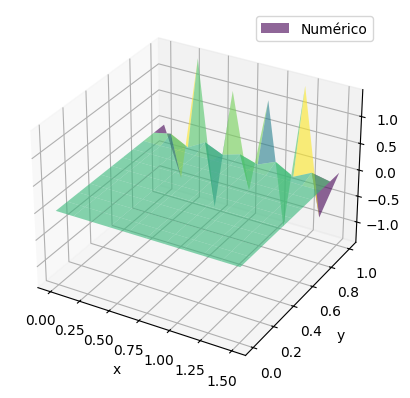

In [8]:
plot_grafico(x,t,w)

### 2. Implicit Method (Backward Euler)

Approximates the spatial derivative at level $j+1$:

$$\frac{w_{i,j+1} - w_{i,j}}{k} = \alpha^2\,\frac{w_{i+1,j+1} - 2w_{i,j+1} + w_{i-1,j+1}}{h^2}$$

**Scheme:**

$$-\lambda\,w_{i-1,j+1} + (1+2\lambda)\,w_{i,j+1} - \lambda\,w_{i+1,j+1} = w_{i,j}$$

Leads to a tridiagonal linear system at each time step:

$$A\,\mathbf{w}^{j+1} = \mathbf{w}^{j}$$

where:

$$A = \begin{pmatrix} 1+2\lambda & -\lambda & & \\ -\lambda & 1+2\lambda & -\lambda & \\ & \ddots & \ddots & \ddots \\ & & -\lambda & 1+2\lambda \end{pmatrix}$$

**Unconditionally stable** for all $\lambda > 0$. Truncation error: $\mathcal{O}(k + h^2)$.


Método implícito:

In [9]:
def parabolica_implicito(l, T, m, n, f):
    h = l/m
    k = T/n
    K = 1.04
    rho = 10.6
    L = 1.5
    C = 0.056
    r = 5

    alpha = 1/K
    lamb = alpha*k/ h**2

    x = np.linspace(0, l, m+1)
    t = np.linspace(0, T, n+1)

    # espaço x tempo
    w = np.zeros((m+1, n+1))

    # condição inicial
    for i in range(m+1):
        w[i,0] = f(x[i])


    a = -lamb * np.ones(m-2)      # superior
    b = (1 + 2 *lamb) * np.ones(m-1)     # principal
    c = -lamb * np.ones(m-2)      # inferior

    # avanço temporal
    for j in range(n):

        rhs = np.zeros(m - 1)

        for i in range(1, m):
            rhs[i - 1] = w[i,j] + k*r / (rho*C)

        sol = thomas_algorithm(
            a.copy(),
            c.copy(),
            b.copy(),
            rhs.copy()
        )

        w[0,j+1] = 0
        w[m,j+1] = 0

        w[1:m, j + 1] = sol

    return x, t, w

In [10]:
x,t,w =  parabolica_implicito(1.5, 1, 10, 67, f)

<Figure size 1500x800 with 0 Axes>

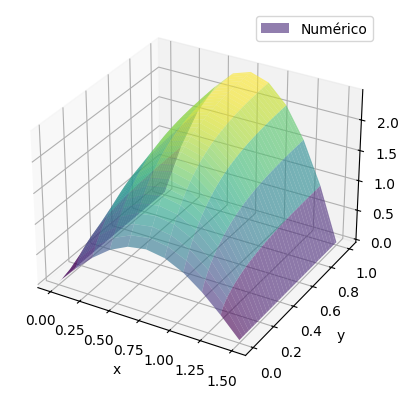

In [11]:
plot_grafico(x,t,w)

### 3. Crank-Nicolson Method

Averages the explicit and implicit schemes, using the spatial derivative at both levels $j$ and $j+1$:

$$\frac{w_{i,j+1} - w_{i,j}}{k} = \frac{\alpha^2}{2}\left(\frac{w_{i+1,j} - 2w_{i,j} + w_{i-1,j}}{h^2} + \frac{w_{i+1,j+1} - 2w_{i,j+1} + w_{i-1,j+1}}{h^2}\right)$$

**Scheme:**

$$-\lambda\,w_{i-1,j+1} + 2(1+\lambda)\,w_{i,j+1} - \lambda\,w_{i+1,j+1} = \lambda\,w_{i-1,j} + 2(1-\lambda)\,w_{i,j} + \lambda\,w_{i+1,j}$$

Leads to the system:

$$A\,\mathbf{w}^{j+1} = B\,\mathbf{w}^{j}$$

where:

$$A = \begin{pmatrix} 2(1+\lambda) & -\lambda & & \\ -\lambda & 2(1+\lambda) & -\lambda & \\ & \ddots & \ddots & \ddots \\ & & -\lambda & 2(1+\lambda) \end{pmatrix}, \quad B = \begin{pmatrix} 2(1-\lambda) & \lambda & & \\ \lambda & 2(1-\lambda) & \lambda & \\ & \ddots & \ddots & \ddots \\ & & \lambda & 2(1-\lambda) \end{pmatrix}$$

**Unconditionally stable** for all $\lambda > 0$. Truncation error: $\mathcal{O}(k^2 + h^2)$.


In [12]:
def parabolica_crank_nicolson(l, T, m, n, f):
    h = l/m
    k = T/n
    K = 1.04
    rho = 10.6
    L = 1.5
    C = 0.056
    r = 5

    alpha = 1/K
    lamb = alpha* k / h**2

    x = np.linspace(0, l, m+1)
    t = np.linspace(0, T, n+1)

    # espaço x tempo
    w = np.zeros((m+1, n+1))

    # condição inicial
    for i in range(m+1):
        w[i,0] = f(x[i])

    # diagonais
    a = -lamb/2 * np.ones(m-2)      # superior
    b = (1+lamb) * np.ones(m-1)     # principal
    c = -lamb/2 * np.ones(m-2)      # inferior

    # avanço temporal
    for j in range(n):

        rhs = np.zeros(m-1)

        for i in range(1, m):
            rhs[i-1] = (
                (1-lamb)*w[i,j]
                + (lamb/2)*(w[i-1,j] + w[i+1,j]) + k*r /(rho*C)
            )

        sol = thomas_algorithm(
            a.copy(),
            c.copy(),
            b.copy(),
            rhs.copy()
        )

        # atualiza os pontos internos no tempo j+1

        w[1:m, j+1] = sol

    return x, t, w

In [13]:
x,t,w =  parabolica_crank_nicolson(1.5, 100, 100, 67, f)

<Figure size 1500x800 with 0 Axes>

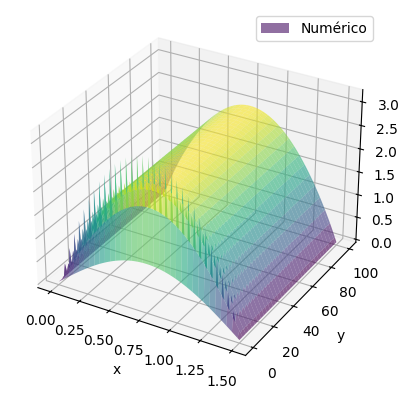

In [14]:
plot_grafico(x,t,w)

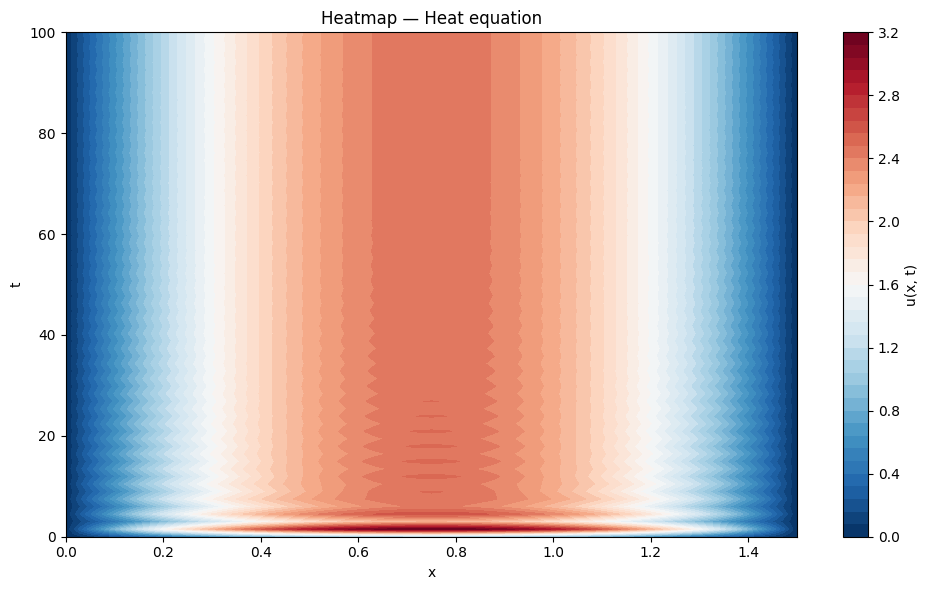

In [15]:
plot_heatmap(x,t,w)